In [1]:
import numpy as np
import xarray as xr

def generate_random_ics(param1_name, param1_coords, 
                        param2_name, param2_coords,
                        state_var_shapes, 
                        max_values):
    """
    Creates an xarray.Dataset of random initial conditions for a 2D scan.

    Parameters
    ----------
    param1_name : str
        Name of the first scan coordinate (e.g., 'HigherOrderMortality__rate').
    param1_coords : array-like
        The scalar coordinate values for the first parameter.
    param2_name : str
        Name of the second scan coordinate (e.g., 'N0__value').
    param2_coords : array-like
        The coordinate values for the second parameter.
    state_var_shapes : dict
        Maps state variable names (from iv_map) to their dimension shapes.
        e.g., {'Nutrient__value': (), 
               'Phytoplankton__biomass': (3,), 
               'Zooplankton__biomass': (4,)}
    max_values : dict
        Maps state variable names to the maximum random value to generate.
        e.g., {'Nutrient__value': 10.0, ...}

    Returns
    -------
    xarray.Dataset
        A dataset with the scan coordinates, filled with random values.
    """
    
    # Get the shape of the 2D parameter grid
    grid_shape = (len(param2_coords), len(param1_coords))
    
    data_vars = {}
    for var_name, shape in state_var_shapes.items():
        # Full shape is (param2_shape, param1_shape) + state_var_shape
        full_shape = grid_shape + shape
        
        # Get the max value for this variable, default to 1.0
        max_val = max_values.get(var_name, 1.0)
        
        # Create random data
        rand_data = max_val * np.random.rand(*full_shape)
        
        # Get the full dimension names
        # e.g., ('N0__value', 'HigherOrderMortality__rate', 'phyto')
        # We must get these from the state_var_shapes dict in the model
        dims = (param2_name, param1_name) + tuple(f'dim_{i}' for i in range(len(shape)))
        
        # This is a bit of a hack; we assume the dim names
        # You may need to replace ('dim_0', 'dim_1') with ('phyto', 'zoo')
        # Let's try to be smarter...
        if var_name == 'Phytoplankton__biomass':
            dims = (param2_name, param1_name, 'phyto')
        elif var_name == 'Zooplankton__biomass':
            dims = (param2_name, param1_name, 'zoo')
        else: # Nutrient
            dims = (param2_name, param1_name)
            
        data_vars[var_name] = (dims, rand_data)

    # Create the coordinate dictionary
    coords = {
        param1_name: param1_coords,
        param2_name: param2_coords
    }
    # Add coordinates for state var dims
    if 'Phytoplankton__biomass' in state_var_shapes:
        coords['phyto'] = np.arange(state_var_shapes['Phytoplankton__biomass'][0])
    if 'Zooplankton__biomass' in state_var_shapes:
        coords['zoo'] = np.arange(state_var_shapes['Zooplankton__biomass'][0])

    return xr.Dataset(data_vars, coords=coords)

In [2]:
def run_multistart_stability_scan(num_starts, 
                                   param1_name, param1_values, param1_coords,
                                   param2_name, param2_values,
                                   iv_map, state_var_shapes, max_values,
                                   **scan_kwargs):
    """
    Runs run_xso_stabilityscan multiple times with random initial conditions.

    Parameters
    ----------
    num_starts : int
        Number of random initial condition sets to try (e.g., 5).
    param1_name, param1_values, param1_coords :
        Scan parameters for the first dimension.
        'param1_values' is the raw list (with arrays)
        'param1_coords' is the scalar list for the xarray coordinates
    param2_name, param2_values :
        Scan parameters for the second dimension.
    iv_map : dict
        Mapping of {dataset_var_name: model_init_param_name}.
    state_var_shapes : dict
        Shapes of the state variables (for the generator).
    max_values : dict
        Max random values (for the generator).
    **scan_kwargs :
        Other arguments to pass to run_xso_stabilityscan
        (e.g., model_file_name, model_setup_name, processes).
        
    Returns
    -------
    xarray.Dataset
        A combined dataset with a new 'solution_id' dimension.
    """
    
    all_results = []
    
    for i in range(num_starts):
        print(f"--- Starting Multi-Start Run {i+1} of {num_starts} ---")
        
        # 1. Generate a new set of random initial conditions
        random_ics_ds = generate_random_ics(
            param1_name=param1_name,
            param1_coords=param1_coords,
            param2_name=param2_name,
            param2_coords=param2_values, # param2 is scalar
            state_var_shapes=state_var_shapes,
            max_values=max_values
        )
        
        # 2. Run the stability scan
        stability_results = run_xso_stabilityscan(
            param_name=param1_name,
            param_values=param1_values,
            param_name2=param2_name,
            param_values2=param2_values,
            initial_values_ds=random_ics_ds,
            iv_mapping=iv_map,
            **scan_kwargs 
        )
        
        # 3. If successful, add a 'solution_id' and save
        if stability_results is not None:
            stability_results = stability_results.assign_coords(solution_id=i)
            all_results.append(stability_results)
        else:
            print(f"Run {i+1} failed to complete.")
            
    if not all_results:
        print("All stability scans failed.")
        return None
        
    # 4. Combine all datasets along the new dimension
    print("Combining results from all runs...")
    combined_ds = xr.concat(all_results, dim='solution_id')
    return combined_ds

In [20]:
import numpy as np
import xarray as xr
from xso.parscans import run_xso_parscan, run_xso_stabilityscan
# Make sure your helper functions from above are defined here

# --- 1. Define Scan Parameters ---
higherordermortality = np.linspace(0.005, 0.04, 20)
# 'ivp_param_values' is the list of arrays for the *scan*
ivp_param_values = [np.array([0, 0, 0, val]) for val in higherordermortality]
# 'higherordermortality' is the list of scalars for the *coordinates*
ivp_param_values2 = np.linspace(0.002, 0.0055, 20)

# --- 2. Define Initial Condition Generation Details ---

# This maps {IVP output name: Model input name}
# We re-use this to name variables in our random dataset
iv_map = {
    'Nutrient__value': 'Nutrient__value_init',
    'Phytoplankton__biomass':'Phytoplankton__biomass_init',
    'Zooplankton__biomass':'Zooplankton__biomass_init'
}

# This tells the generator what shapes to make
state_var_shapes = {
    'Nutrient__value': (),
    'Phytoplankton__biomass': (3,),
    'Zooplankton__biomass': (4,)
}

# This sets the *scale* of the random numbers (e.g., 0 to 10)
# Adjust these based on your model's expected scales!
max_values = {
    'Nutrient__value':1.5,
    'Phytoplankton__biomass': 5.5,
    'Zooplankton__biomass': 2.5
}

# --- 3. Run the Multi-Start Scan ---
N_STARTS = 15  # Try 5 different random starting points

# These are the keyword args for run_xso_stabilityscan
scan_kwargs = {
    'model_file_name': 'Stocketal2008',
    'model_setup_name': 'model_setup_stability',
    'processes': 20
}

all_solutions = run_multistart_stability_scan(
    num_starts=N_STARTS,
    param1_name='HigherOrderMortality__rate',
    param1_values=ivp_param_values,
    param1_coords=higherordermortality, # The scalar coords
    param2_name='N0__value',
    param2_values=ivp_param_values2,
    iv_map=iv_map,
    state_var_shapes=state_var_shapes,
    max_values=max_values,
    **scan_kwargs
)

# Display the result
if all_solutions is not None:
    print("\nFinal Combined Output Dataset:")
    print(all_solutions)

PROGRESS: Completed 20/20 outer points. (HigherOrderMortality__rate = [0.         0.         0.         0.03447368]).

2D Stability Scan complete. Total Time taken: 4.14123 seconds.
Combining results from all runs...

Final Combined Output Dataset:
<xarray.Dataset> Size: 11MB
Dimensions:                                         (solution_id: 15,
                                                     N0__value: 20,
                                                     HigherOrderMortality__rate: 20,
                                                     zoo: 4, time: 2, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * HigherOrderMortality__rate                      (HigherOrderMortality__rate) float64 160B ...
  * N0__value                                       (N0__value) float64 160B ...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
 

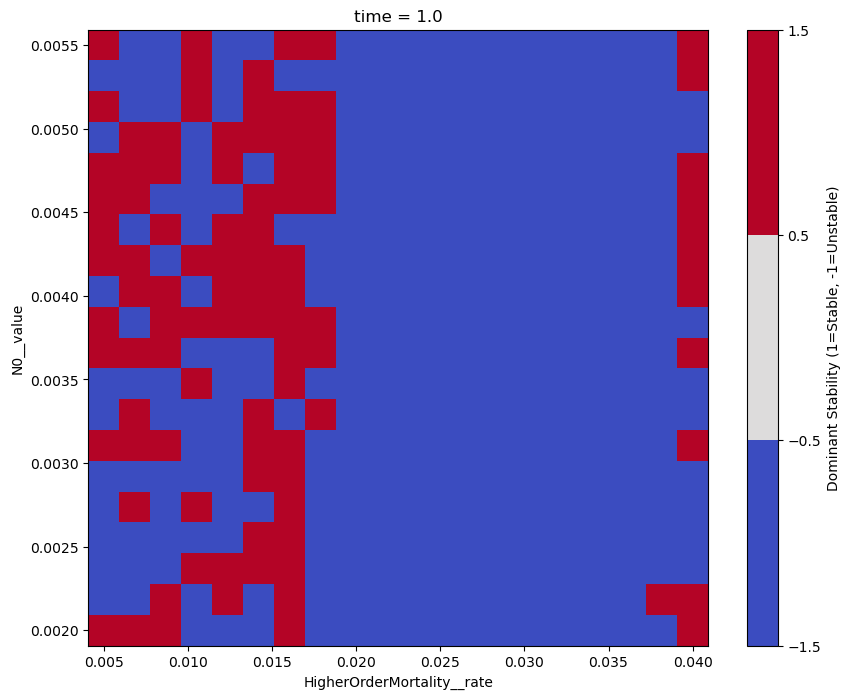

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

if all_solutions is not None:
    # --- 1. Create 3D masks (with 'solution_id' dim) ---
    is_stable = (all_solutions['stability'] == 'stable')
    is_unstable = (all_solutions['stability'] == 'unstable')

    steady_state = all_solutions.isel(time=-1)
    threshold = 1e-6 
    phyto_ok = steady_state['Phytoplankton__biomass'].all(dim='phyto') > threshold
    zoo_ok = steady_state['Zooplankton__biomass'].all(dim='zoo') > threshold
    nutrient_ok = steady_state['Nutrient__value'] > threshold
    is_meaningful = phyto_ok & zoo_ok & nutrient_ok

    # --- 2. Create 3D masks for categories ---
    stable_and_meaningful = is_stable & is_meaningful
    unstable_and_meaningful = is_unstable & is_meaningful
    washout = ~is_meaningful
    failed = all_solutions['stability'].isnull()

    # --- 3. Collapse the 'solution_id' dimension based on priority ---
    # We use .any() to see if *any* of the N_STARTS found this type of solution.
    has_stable_meaningful = stable_and_meaningful.any(dim='solution_id')
    has_unstable_meaningful = unstable_and_meaningful.any(dim='solution_id')
    # Check if *any* run resulted in a washout AND no runs were stable/unstable
    has_only_washout = (washout.any(dim='solution_id') & 
                        ~has_stable_meaningful & 
                        ~has_unstable_meaningful)
    # Check if *all* runs failed (produced NaN)
    all_runs_failed = failed.all(dim='solution_id')

    # --- 4. Build the 2D plot_array based on priority ---
    # Start with all NaNs
    plot_array = xr.full_like(has_stable_meaningful, np.nan, dtype=float)

    # Rule 1: Stable and meaningful (1.0)
    plot_array = xr.where(has_stable_meaningful, 1.0, plot_array)
    # Rule 2: Unstable and meaningful (-1.0)
    plot_array = xr.where(~has_stable_meaningful & has_unstable_meaningful, -1.0, plot_array)

    # --- 5. Plot this new plot_array ---
    plt.figure(figsize=(10, 8))
    ax1 = plt.gca() # Get current axis

    # Plot the heatmap
    plot_array.plot(
        ax=ax1,
        cmap='coolwarm',
        levels=[-1.5, -0.5, 0.5, 1.5], # Bins for -1, 1
        cbar_kwargs={'label': 'Dominant Stability (1=Stable, -1=Unstable)'},
        zorder=1
    )

    plt.savefig("plots/Stability_fsolve_10starts_03.pdf", format='pdf', bbox_inches='tight')
    plt.show()

else:
    print("The 'all_solutions' dataset is not defined. Please run the multi-start scan first.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import xarray as xr
import matplotlib.colors as mcolors

# --- Assumed Datasets ---
# all_solutions = ... (from your multi-start stability scan)
# KsZ_mort_scan_X = ... (from your IVP scan, e.g., ivp_results)
# ------------------------


## 1. Generate the 2D Stability Map
# This code block "collapses" your multi-start results into one 2D map.

# Start with all NaNs
plot_array = xr.full_like(all_solutions['stability'].isel(solution_id=0, drop=True), np.nan, dtype=float)

if all_solutions is not None:
    # --- Create 3D masks (with 'solution_id' dim) ---
    is_stable = (all_solutions['stability'] == 'stable')
    is_unstable = (all_solutions['stability'] == 'unstable')

    steady_state = all_solutions.isel(time=-1)
    threshold = 1e-6 
    is_meaningful = (steady_state['Phytoplankton__biomass'].all(dim='phyto') > threshold) & \
                    (steady_state['Zooplankton__biomass'].all(dim='zoo') > threshold) & \
                    (steady_state['Nutrient__value'] > threshold)

    # --- Create 3D masks for categories ---
    stable_and_meaningful = is_stable & is_meaningful
    unstable_and_meaningful = is_unstable & is_meaningful

    # --- Collapse the 'solution_id' dimension based on priority ---
    has_stable_meaningful = stable_and_meaningful.any(dim='solution_id')
    has_unstable_meaningful = unstable_and_meaningful.any(dim='solution_id')

    # --- Build the 2D plot_array based on priority ---
    # Rule 1: Stable and meaningful (1.0)
    plot_array = xr.where(has_stable_meaningful, 1.0, plot_array)
    # Rule 2: Unstable and meaningful (-1.0)
    plot_array = xr.where(~has_stable_meaningful & has_unstable_meaningful, -1.0, plot_array)
    
print("Stability map generated.")


## 2. Generate the Parameter Fit Plot and Overlay Stability
# This is your plotting code, with the stability overlay added.

# --- Parameters ---
target_composition = np.array([0.308, 0.290, 0.402])
start_time = 365 * 9
end_time = 365 * 10

# --- Slice and average over the last year ---
biomass = KsZ_mort_scan_X.Phytoplankton__biomass.isel(time=slice(start_time, end_time))
biomass_mean = biomass.mean(dim='time')

# Transpose so dimensions are (HigherOrderMortality__rate, N0__value, phyto)
biomass_mean = biomass_mean.transpose('HigherOrderMortality__rate', 'N0__value', 'phyto')

# --- Normalize each (i,j) point to relative composition ---
total_biomass = biomass_mean.sum(dim='phyto')
relative_composition = biomass_mean / total_biomass
relative_composition = relative_composition.fillna(0)

# --- Compute distance to target composition ---
rel_np = relative_composition.values
dist = np.linalg.norm(rel_np - target_composition, axis=2)
print(f"Minimum distance found: {dist.min()}")

# Normalize and compute brightness
dist_max = np.percentile(dist, 95)
dist_clipped = np.clip(dist, 0, dist_max)
dist_norm = dist_clipped / dist_max
brightness = 1 - dist_norm

# Apply gamma correction
gamma = 0.5
brightness_gamma = brightness ** gamma
rgb = rel_np * brightness_gamma[..., np.newaxis]

# Clean up RGB array for imshow
rgb = np.nan_to_num(rgb, nan=0.0)
rgb = np.clip(rgb, 0, 1)

# --- Prepare coordinate grids for contour ---
x_vals = biomass_mean.N0__value.values
y_vals = biomass_mean.HigherOrderMortality__rate.values
X, Y = np.meshgrid(x_vals, y_vals)

# --- Plot ---
plt.figure(figsize=(10, 6))
# Get the axis object for overlaying
ax = plt.gca()

# Plot the RGB composition/fit
ax.imshow(rgb, origin='lower', aspect='auto',
          extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
          zorder=1)

ax.set_xlabel('N0__value')
ax.set_ylabel('HigherOrderMortality__rate')
ax.set_title('Phytoplankton Composition Fit & System Stability\nRGB = Composition, Brightness = Fit, Hatched = Unstable')
ax.grid(False)

# Overlay contour for perfect match:
levels = [0.02, 0.05, 0.1, 0.2]
cmap = mcolors.LinearSegmentedColormap.from_list("grey_white", ["grey", "white"], N=256)
cs = ax.contour(X, Y, dist, levels=levels, colors=cmap(np.linspace(1, 0, len(levels))), 
                linewidths=1.5, zorder=3)


# --- !!! NEW: OVERLAY STABILITY MAP !!! ---

# Create a mask for all unstable regions
# We must transpose plot_array to match the (Y, X) dimension order of imshow
# imshow Y-dim = HigherOrderMortality__rate (from rgb.shape[0])
# imshow X-dim = N0__value (from rgb.shape[1])
# We assume plot_array's dims are ('N0__value', 'HigherOrderMortality__rate')
# So we transpose them.
try:
    plot_array_T = plot_array.transpose('HigherOrderMortality__rate', 'N0__value')
    
    # Create a mask where the value is -1.0 (unstable)
    unstable_mask = (plot_array_T == -1.0)
    
    # Use xarray's contourf to plot *only* the hatching
    unstable_mask.plot.contourf(
        ax=ax,
        levels=[0.5, 1.5],     # This captures the 'True' (or 1.0) values
        colors='none',         # Do not draw a fill
        hatches=['///'],       # Draw diagonal hatches
        add_colorbar=False,    # No colorbar
        zorder=2               # Draw it on top of imshow, under fit contours
    )
    print("Overlaying unstable regions with hatching...")

except Exception as e:
    print(f"Could not overlay stability. Check dimension names. Error: {e}")

# --- Update Legend ---
legend_elements = [
    Patch(facecolor='red', label='Phyto 1 dominates'),
    Patch(facecolor='green', label='Phyto 2 dominates'),
    Patch(facecolor='blue', label='Phyto 3 dominates'),
    Patch(facecolor='white', label='Contour: Good match to target'),
    Patch(facecolor='black', label='Dark: Poor match to target'),
    Patch(facecolor='grey', hatch='///', label='Region is Unstable') # New patch
]
ax.legend(handles=legend_elements, loc='upper left')

plt.savefig("ParScan_With_Stability_Overlay.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [3]:
import numpy as np
import xarray as xr
from xso.parscans import run_xso_parscan, run_xso_stabilityscan


# --- 1. Run the IVP Scan ---
print("Running IVP scan...")
higherordermortality = np.linspace(0.005,0.04, 100)
ivp_param_values = [np.array([0, 0, 0, val]) for val in higherordermortality]
ivp_param_values2 = np.linspace(0.002,0.0055, 100)


ivp_results = run_xso_parscan(
    model_file_name='Stocketal2008',
    model_name='model',
    model_setup_name='model_setup_ivp', # <-- Your IVP setup
    param_name='HigherOrderMortality__rate',
    param_values=ivp_param_values,
    param_name2='N0__value',
    param_values2=ivp_param_values2,
    processes=20
)

if ivp_results is None:
    raise RuntimeError("IVP scan failed. Aborting.")

PROGRESS: Completed 100/100 outer points. (HigherOrderMortality__rate = [0.   0.   0.   0.04]).

2D Scan complete. Total Time taken: 1941.07995 seconds.


In [12]:

# --- 2. Calculate Mean of Last 1000 Steps ---
print("Calculating mean values for initial conditions...")
# Select variables and get the mean of the last 1000 time steps
mean_results = ivp_results[['Nutrient__value','Phytoplankton__biomass', 'Zooplankton__biomass']] \
                         .isel(time=slice(-1000, None)) \
                         .mean(dim='time')

print(mean_results)



Calculating mean values for initial conditions...


NameError: name 'ivp_results' is not defined

In [5]:

# --- 3. Define the Initial Value Mapping ---
# Maps: {Variable name in mean_results} -> {Parameter name in model_setup_stability}
iv_map = {
    'Nutrient__value': 'Nutrient__value_init',
    'Phytoplankton__biomass':'Phytoplankton__biomass_init',
    'Zooplankton__biomass':'Zooplankton__biomass_init'
}

# --- 4. Run the Stability Scan ---
print("Running stability scan with dynamic initial values...")
stability_results = run_xso_stabilityscan(
    model_file_name='Stocketal2008',
    model_setup_name='model_setup_stability', # <-- Your stability setup
    param_name='HigherOrderMortality__rate',
    param_values=ivp_param_values,       # Must be the same parameter range
    param_name2='N0__value',
    param_values2=ivp_param_values2,     # Must be the same parameter range
    processes=20,
    initial_values_ds=mean_results,      # <-- Pass the mean results
    iv_mapping=iv_map                    # <-- Pass the name mapping
)

# Display the final result
if stability_results is not None:
    print("\nFinal Stability Scan Output Dataset:")
    print(stability_results)
    print("\nStability data:")
    print(stability_results['stability'])

PROGRESS: Completed 100/100 outer points. (HigherOrderMortality__rate = [0.         0.         0.         0.03964646]).

2D Stability Scan complete. Total Time taken: 38.88938 seconds.

Final Stability Scan Output Dataset:
<xarray.Dataset> Size: 18MB
Dimensions:                                         (N0__value: 100,
                                                     HigherOrderMortality__rate: 100,
                                                     zoo: 4, time: 2, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * HigherOrderMortality__rate                      (HigherOrderMortality__rate) float64 800B ...
  * N0__value                                       (N0__value) float64 800B ...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 16B 0.0 1.0
  * zoo         

In [6]:
import matplotlib.pyplot as plt
import numpy as np

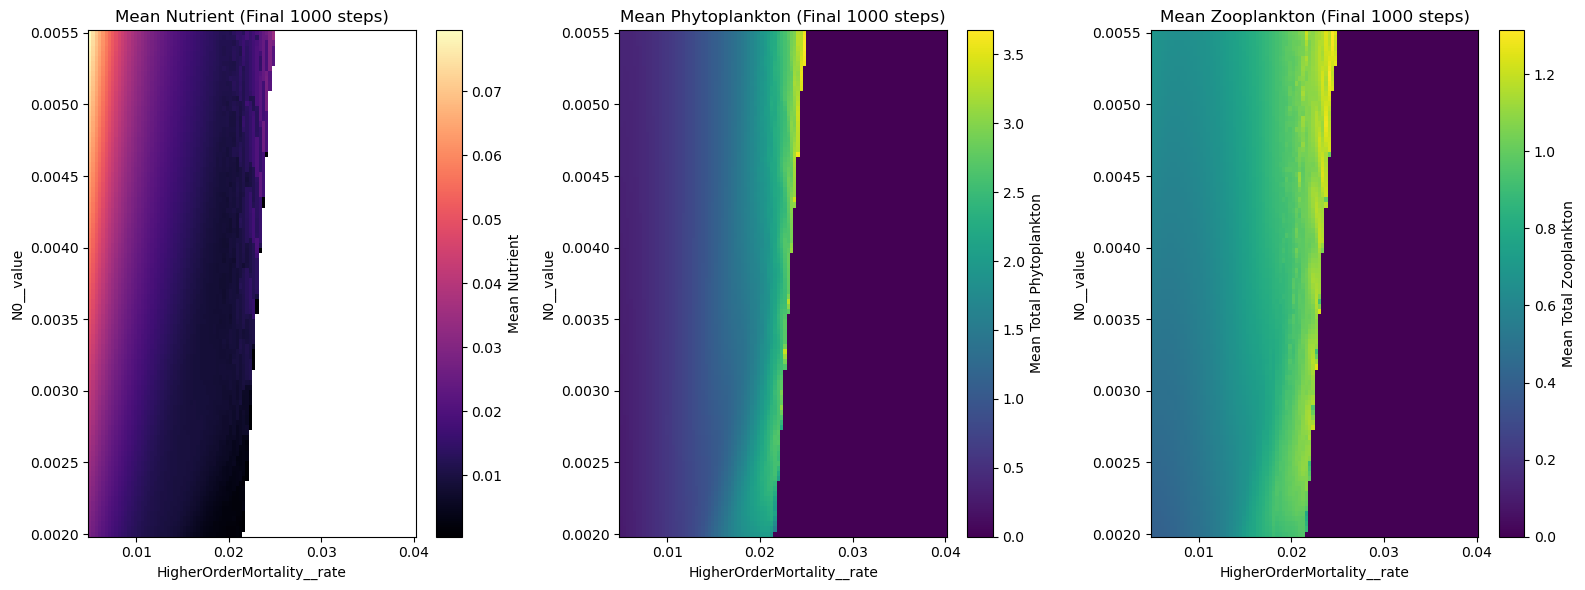

In [8]:
# Assuming 'mean_results' is your dataset with mean values
# and has variables 'Phytoplankton__biomass' and 'Nutrient__value'

# Create a figure with two subplots, side-by-side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))


# Plot 2: Nutrient mean value
mean_results['Nutrient__value'].plot(
    ax=ax1,
    cmap='magma',
    cbar_kwargs={'label': 'Mean Nutrient'}
)
ax1.set_title('Mean Nutrient (Final 1000 steps)')

# Plot 1: Phytoplankton mean value
# We sum over the 'phyto' dimension to get a single 2D value
mean_results['Phytoplankton__biomass'].sum(dim='phyto').plot(
    ax=ax2,
    cmap='viridis',  # 'cmap' sets the colormap
    cbar_kwargs={'label': 'Mean Total Phytoplankton'}
)
ax2.set_title('Mean Phytoplankton (Final 1000 steps)')


mean_results['Zooplankton__biomass'].sum(dim='zoo').plot(
    ax=ax3,
    cmap='viridis',  # 'cmap' sets the colormap
    cbar_kwargs={'label': 'Mean Total Zooplankton'}
)
ax3.set_title('Mean Zooplankton (Final 1000 steps)')

plt.tight_layout()

plt.savefig("plots/Stability_output_solve_02.pdf", format='pdf', bbox_inches='tight')
plt.show()

Plotting 'x' markers at 2908 non-meaningful locations.


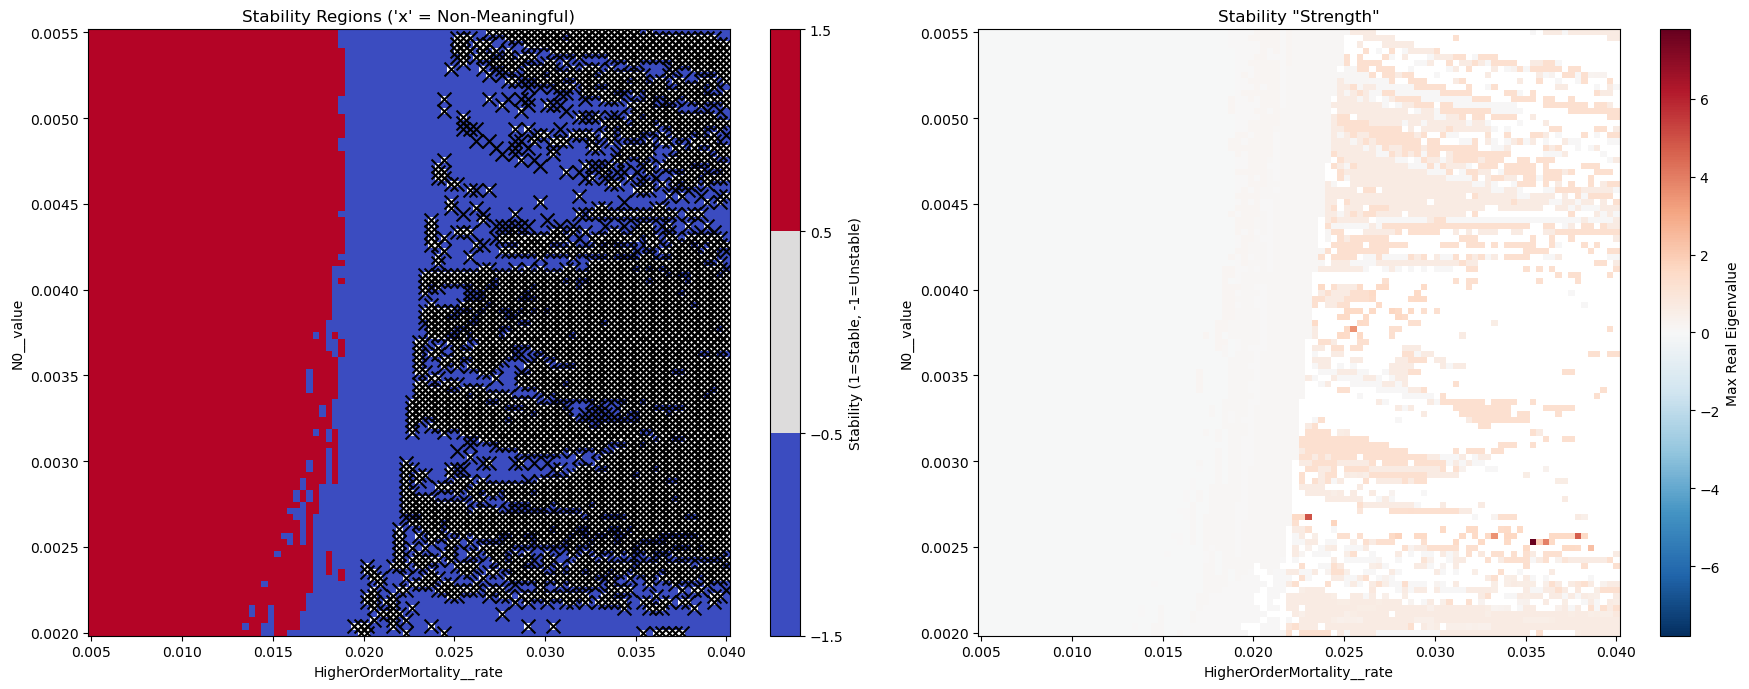

In [9]:

import xarray as xr
# --- HIGHLIGHTED FIX: Check for the 'None' object, not the string "None" ---
if stability_results is not None:
    # --- 1. CREATE THE BASE STABILITY PLOT ---
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    stability_map = {'stable': 1.0, 'unstable': -1.0, 'marginal': 0.0, np.nan: np.nan}
    numeric_stability = xr.apply_ufunc(lambda x: stability_map.get(x, np.nan), 
                                     stability_results['stability'], 
                                     vectorize=True)
    
    numeric_stability.plot(
        ax=ax1,
        cmap='coolwarm',
        levels=[-1.5, -0.5, 0.5, 1.5],
        cbar_kwargs={'label': 'Stability (1=Stable, -1=Unstable)'},
        zorder=1
    )

    # --- 2. CREATE THE "MEANINGFUL STATE" MASK ---
    
    steady_state = stability_results.isel(time=-1)
    threshold = 1e-6 
    
    phyto_ok = steady_state['Phytoplankton__biomass'].all(dim='phyto') > threshold
    zoo_ok = steady_state['Zooplankton__biomass'].all(dim='zoo') > threshold
    nutrient_ok = steady_state['Nutrient__value'] > threshold
    
    meaningful_mask = phyto_ok & zoo_ok & nutrient_ok
    non_meaningful_overlay = xr.where(meaningful_mask, np.nan, 1.0)

    # --- 3. ADD THE 'X' MARKER OVERLAY (ROBUST METHOD) ---
    
    # Find the indices of the cells to plot
    y_indices, x_indices = np.where(np.isfinite(non_meaningful_overlay.values))
    
    if len(x_indices) > 0:
        # Get the coordinate *values* at those indices
        x_coords = non_meaningful_overlay['HigherOrderMortality__rate'].values[x_indices]
        y_coords = non_meaningful_overlay['N0__value'].values[y_indices]
        
        # Use matplotlib's scatter directly
        ax1.scatter(
            x_coords, 
            y_coords, 
            marker='x', 
            color='black', 
            s=100,  # Adjust size as needed
            zorder=2
        )
        print(f"Plotting 'x' markers at {len(x_indices)} non-meaningful locations.")
    else:
        print("All steady states are ecologically meaningful. No 'x' markers to plot.")

    ax1.set_title("Stability Regions ('x' = Non-Meaningful)")

    # --- 4. PLOT MAX EIGENVALUE (UNCHANGED) ---
    
    stability_results['max_eigenvalue'].plot(
        ax=ax2,
        cmap='RdBu_r',
        center=0,
        cbar_kwargs={'label': 'Max Real Eigenvalue'}
    )
    ax2.set_title('Stability "Strength"')

    plt.tight_layout()
    
    plt.savefig("plots/Stability_regions_02.pdf", format='pdf', bbox_inches='tight')
    plt.show()

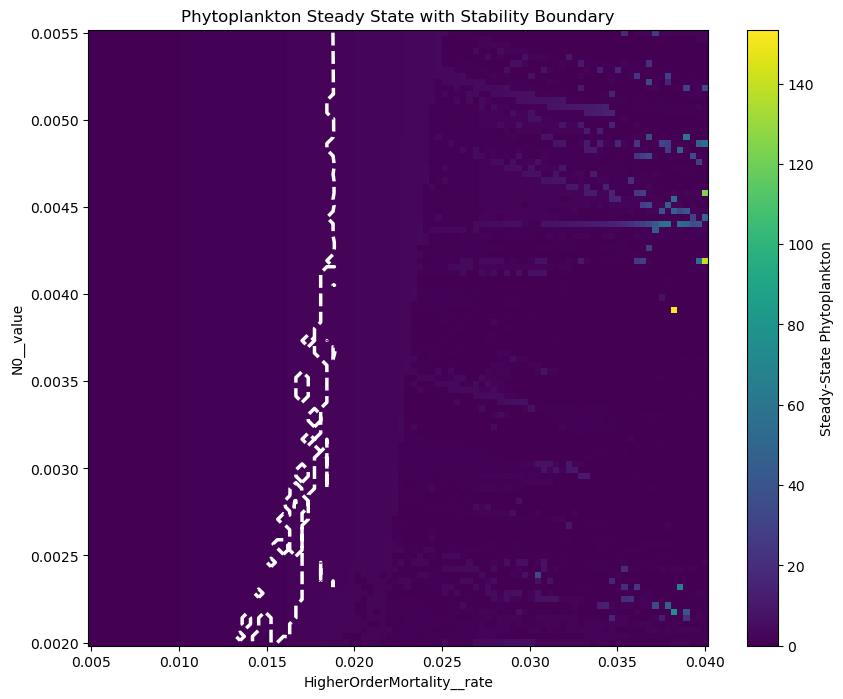

In [10]:
if stability_results is not None:
    plt.figure(figsize=(10, 8))

    # --- HIGHLIGHTED FIX ---
    # 1. Select the steady-state (the *final* time step)
    #    Then sum over the 'phyto' dimension
    steady_phyto = stability_results['Phytoplankton__biomass'].isel(time=-1).sum(dim='phyto')
    # --- END FIX ---
    
    steady_phyto.plot(
        cmap='viridis',
        cbar_kwargs={'label': 'Steady-State Phytoplankton'}
    )

    # 2. Overlay the stability boundary (this part was correct)
    stability_results['max_eigenvalue'].plot.contour(
        levels=[0],      # Only draw the contour at the 0-level
        colors='white',  # Make the line white
        linewidths=2.5,
        linestyles='--'   # Make the line dashed
    )

    plt.title('Phytoplankton Steady State with Stability Boundary')
    plt.savefig("Stability_boundary_02.pdf", format='pdf', bbox_inches='tight')
    plt.show()

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import random

def plot_exemplary_timeseries(ivp_results, stability_results):
    """
    Finds and plots random example time-series from the ivp_results
    that correspond to stable, unstable, and washout steady states.

    Parameters
    ----------
    ivp_results : xarray.Dataset
        The 4D dataset from your 'run_xso_parscan' (time-series).
    stability_results : xarray.Dataset
        The 4D dataset from 'run_xso_stabilityscan' (stability map).
    """
    
    print("Finding exemplary time-series...")

    # --- 1. Re-create the masks from Plot 2 ---
    
    # Create numeric stability map
    stability_map = {'stable': 1.0, 'unstable': -1.0, 'marginal': 0.0, np.nan: np.nan}
    numeric_stability = xr.apply_ufunc(lambda x: stability_map.get(x, np.nan), 
                                     stability_results['stability'], 
                                     vectorize=True)
    
    # Create meaningful/washout mask
    steady_state = stability_results.isel(time=-1)
    threshold = 1e-6 
    phyto_ok = steady_state['Phytoplankton__biomass'].all(dim='phyto') > threshold
    zoo_ok = steady_state['Zooplankton__biomass'].all(dim='zoo') > threshold
    nutrient_ok = steady_state['Nutrient__value'] > threshold
    meaningful_mask = phyto_ok & zoo_ok & nutrient_ok

    # --- 2. Define the three category masks ---
    
    # Category 1: Stable AND meaningful (not washout)
    stable_mask = (numeric_stability == 1.0) & (meaningful_mask == True)
    
    # Category 2: Unstable AND meaningful (not washout)
    unstable_mask = (numeric_stability == -1.0) & (meaningful_mask == True)
    
    # Category 3: Washout (non-meaningful)
    washout_mask = (meaningful_mask == False)
    
    # --- 3. Helper function to get a random sample ---
    
    def _get_random_selector(mask):
        """Finds all points in a mask and returns a random one."""
        # Get coordinate names, e.g., ('N0__value', 'HigherOrderMortality__rate')
        dim1, dim2 = mask.dims
        
        # Get the 2D indices (y, x) of all 'True' points
        y_indices, x_indices = np.where(mask.values)
        
        if len(x_indices) == 0:
            return None, None  # No points found for this category
        
        # Pick one random index from the list of found points
        rand_idx = random.choice(range(len(x_indices)))
        sample_x_idx = x_indices[rand_idx]
        sample_y_idx = y_indices[rand_idx]
        
        # Get the coordinate *values* at that index
        p1_val = mask[dim2].values[sample_x_idx]
        p2_val = mask[dim1].values[sample_y_idx]
        
        # This is the dictionary we use with .sel()
        selector = {dim1: p2_val, dim2: p1_val}
        
        # Create a title for the plot
        title_str = f"{dim1}={p2_val:.4f}, {dim2}={p1_val:.4f}"
        
        return selector, title_str

    # --- 4. Get the three random selectors ---
    stable_sel, stable_title = _get_random_selector(stable_mask)
    unstable_sel, unstable_title = _get_random_selector(unstable_mask)
    washout_sel, washout_title = _get_random_selector(washout_mask)
    
    # --- 5. Create the plot ---
    fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)
    
    # Plot 1: Stable
    if stable_sel:
        ts = ivp_results.sel(stable_sel)
        ts['Phytoplankton__biomass'].sum(dim='phyto').plot.line(x='time', ax=axes[0], label='Total Phyto')
        ts['Zooplankton__biomass'].sum(dim='zoo').plot.line(x='time', ax=axes[0], label='Total Zoo')
        ts['Nutrient__value'].plot.line(x='time', ax=axes[0], label='Nutrient')
        axes[0].set_title(f"Example 1: Stable & Meaningful\n({stable_title})")
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.5)
    else:
        axes[0].set_title("No 'Stable & Meaningful' points found")

    # Plot 2: Unstable
    if unstable_sel:
        ts = ivp_results.sel(unstable_sel)
        ts['Phytoplankton__biomass'].sum(dim='phyto').plot.line(x='time', ax=axes[1], label='Total Phyto')
        ts['Zooplankton__biomass'].sum(dim='zoo').plot.line(x='time', ax=axes[1], label='Total Zoo')
        ts['Nutrient__value'].plot.line(x='time', ax=axes[1], label='Nutrient')
        axes[1].set_title(f"Example 2: Unstable & Meaningful (Likely Oscillations)\n({unstable_title})")
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.5)
    else:
        axes[1].set_title("No 'Unstable & Meaningful' points found")

    # Plot 3: Washout
    if washout_sel:
        ts = ivp_results.sel(washout_sel)
        ts['Phytoplankton__biomass'].sum(dim='phyto').plot.line(x='time', ax=axes[2], label='Total Phyto')
        ts['Zooplankton__biomass'].sum(dim='zoo').plot.line(x='time', ax=axes[2], label='Total Zoo')
        ts['Nutrient__value'].plot.line(x='time', ax=axes[2], label='Nutrient')
        axes[2].set_title(f"Example 3: Washout / Non-Meaningful\n({washout_title})")
        axes[2].legend()
        axes[2].grid(True, linestyle='--', alpha=0.5)
    else:
        axes[2].set_title("No 'Washout' points found")
        
    plt.xlabel("Time")
    plt.tight_layout()
    
    plt.savefig("Stability_exemplaryRuns_02.pdf", format='pdf', bbox_inches='tight')
    plt.show()

Finding exemplary time-series...


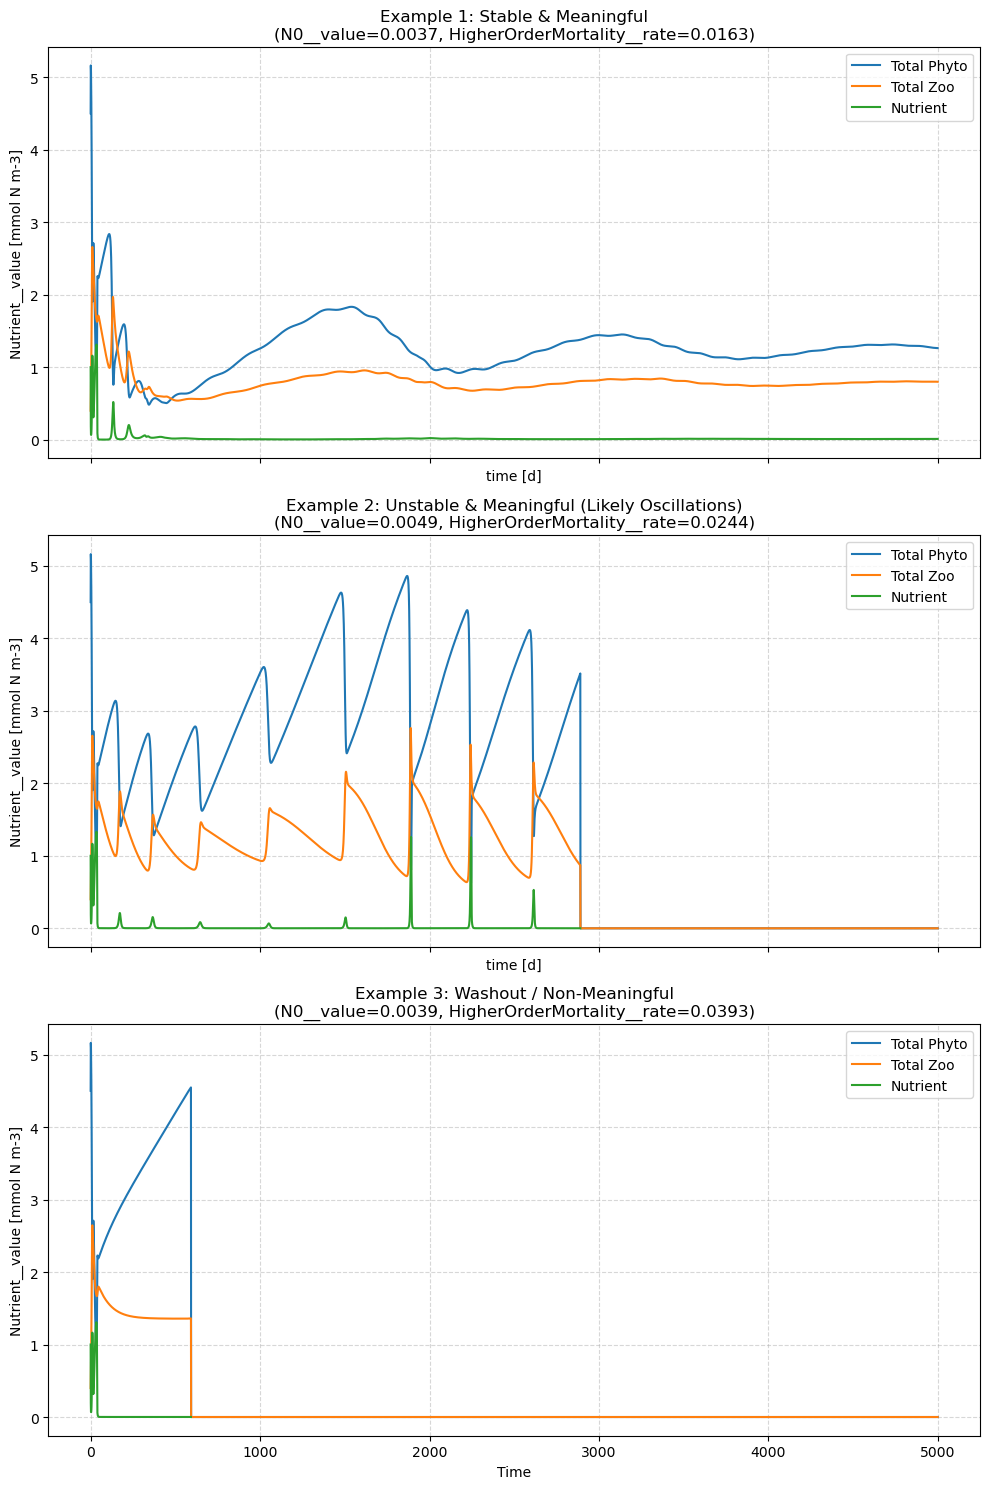

In [12]:
# Assuming you have:
# ivp_results (from run_xso_parscan)
# stability_results (from run_xso_stabilityscan)

plot_exemplary_timeseries(ivp_results, stability_results)

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import xarray as xr
import matplotlib.colors as mcolors

# --- Assumed Datasets ---
# ivp_results:       Your dataset from run_xso_parscan (the time-series).
# stability_results: Your dataset from run_xso_stabilityscan (the fsolve run).
# ------------------------


## 1. Generate the 2D Stability Map
# We convert your 2D 'stability_results' into the overlay masks.

print("Generating 2D stability map from 'stability_results'...")

# --- Create numeric map
# {'stable': 1.0, 'unstable': -1.0, 'marginal': 0.0, np.nan: np.nan}
stability_map = {'stable': 1.0, 'unstable': -1.0, 'marginal': 0.0, np.nan: np.nan}
numeric_stability = xr.apply_ufunc(lambda x: stability_map.get(x, np.nan),
                                 stability_results['stability'],
                                 vectorize=True)

# --- Create meaningful mask
steady_state = stability_results.isel(time=-1) # Select final state
threshold = 1e-6 
is_meaningful = (steady_state['Phytoplankton__biomass'].all(dim='phyto') > threshold) & \
                (steady_state['Zooplankton__biomass'].all(dim='zoo') > threshold) & \
                (steady_state['Nutrient__value'] > threshold)

# --- Build the 2D plot_array
# We get the stability value (1.0 or -1.0) *only* where it's meaningful
plot_array = numeric_stability.where(is_meaningful) 

# --- Create the specific mask for *only* unstable regions
# This will be used for the hatching
unstable_mask = (plot_array == -1.0)

print("Stability map for overlay generated.")


## 2. Generate the Parameter Fit Plot and Overlay Stability
# This is your plotting code, using 'ivp_results' and the 'unstable_mask'.

# --- Parameters ---
target_composition = np.array([0.308, 0.290, 0.402])
start_time = 365 * 9
end_time = 365 * 10

# --- Slice and average over the last year ---
# Use 'ivp_results' (your new dataset name)
biomass = ivp_results.Phytoplankton__biomass.isel(time=slice(start_time, end_time))
biomass_mean = biomass.mean(dim='time')

# Transpose so dimensions are (HigherOrderMortality__rate, N0__value, phyto)
biomass_mean = biomass_mean.transpose('HigherOrderMortality__rate', 'N0__value', 'phyto')

# --- Normalize each (i,j) point to relative composition ---
total_biomass = biomass_mean.sum(dim='phyto')
relative_composition = biomass_mean / total_biomass
relative_composition = relative_composition.fillna(0)

# --- Compute distance to target composition ---
rel_np = relative_composition.values
dist = np.linalg.norm(rel_np - target_composition, axis=2)
print(f"Minimum distance found: {dist.min()}")

# Normalize and compute brightness
dist_max = np.percentile(dist, 95)
dist_clipped = np.clip(dist, 0, dist_max)
dist_norm = dist_clipped / dist_max
brightness = 1 - dist_norm

# Apply gamma correction
gamma = 0.5
brightness_gamma = brightness ** gamma
rgb = rel_np * brightness_gamma[..., np.newaxis]

# Clean up RGB array for imshow
rgb = np.nan_to_num(rgb, nan=0.0)
rgb = np.clip(rgb, 0, 1)

# --- Prepare coordinate grids for contour ---
x_vals = biomass_mean.N0__value.values
y_vals = biomass_mean.HigherOrderMortality__rate.values
X, Y = np.meshgrid(x_vals, y_vals)

# --- Plot ---
plt.figure(figsize=(10, 6))
# Get the axis object for overlaying
ax = plt.gca()

# Plot the RGB composition/fit
ax.imshow(rgb, origin='lower', aspect='auto',
          extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
          zorder=1)

ax.set_xlabel('N0__value')
ax.set_ylabel('HigherOrderMortality__rate')
ax.set_title('Phytoplankton Composition Fit & System Stability\nRGB = Composition, Brightness = Fit, Hatched = Unstable')
ax.grid(False)

# Overlay contour for perfect match:
levels = [0.02, 0.05, 0.1, 0.2]
cmap = mcolors.LinearSegmentedColormap.from_list("grey_white", ["grey", "white"], N=256)
cs = ax.contour(X, Y, dist, levels=levels, colors=cmap(np.linspace(1, 0, len(levels))), 
                linewidths=1.5, zorder=3)


# --- !!! OVERLAY STABILITY MAP !!! ---

# We must transpose our 'unstable_mask' to match the (Y, X) dimension order
# of imshow, which is (HigherOrderMortality__rate, N0__value).
try:
    unstable_mask_T = unstable_mask.transpose('HigherOrderMortality__rate', 'N0__value')
    
    # Use xarray's contourf to plot *only* the hatching
    unstable_mask_T.plot.contourf(
        ax=ax,
        levels=[0.5, 1.5],     # This captures the 'True' (or 1.0) values
        colors='none',         # Do not draw a fill
        hatches=['///'],       # Draw diagonal hatches
        add_colorbar=False,    # No colorbar
        zorder=2               # Draw it on top of imshow, under fit contours
    )
    print("Overlaying unstable regions with hatching...")

except Exception as e:
    print(f"Could not overlay stability. Check dimension names. Error: {e}")

# --- Update Legend ---
legend_elements = [
    Patch(facecolor='red', label='Phyto 1 dominates'),
    Patch(facecolor='green', label='Phyto 2 dominates'),
    Patch(facecolor='blue', label='Phyto 3 dominates'),
    Patch(facecolor='white', label='Contour: Good match to target'),
    Patch(facecolor='black', label='Dark: Poor match to target'),
    Patch(facecolor='grey', hatch='///', label='Region is Unstable') # New patch
]
ax.legend(handles=legend_elements, loc='upper left')

#plt.savefig("ParScan_With_Stability_Overlay.pdf", format='pdf', bbox_inches='tight')
plt.show()

Generating 2D stability map from 'stability_results'...


NameError: name 'stability_results' is not defined